# 05 · Taylor Serisi
**Calculus Lab** — Faz 1'in Son Notebook'u

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bu, `calculus-lab`'ın (ve dolayısıyla tüm Faz 1 matematiksel temellerinin) son
> notebook'u. Taylor serisi, karmaşık bir fonksiyonu, bir noktadaki türevlerini kullanarak
> BASİT bir polinomla yaklaşıklama yöntemi. İlk bakışta "sadece bir yaklaşıklık tekniği"
> gibi görünebilir, ama 02'deki Hessian bilgini **Newton's Method** ile optimizasyona
> bağlıyor — 04'teki gradient descent'in "eğrilik bilgisini de kullanan" daha hızlı bir
> kuzeni. Bu notebook'u bitirdiğinde, `probability-lab`'dan başlayan tüm matematiksel
> temel serisi tamamlanmış olacak.

**Önkoşul:** Türev/Gradyan (01), Jacobian/Hessian (02), Gradient Descent (04)  
**Veri:**  
- `world_population.csv` — 234 ülke/bölge, 1970-2022 arası nüfus verisi  
- Bilinen fonksiyonlar ($\sin x$, $e^x$) — Taylor yakınsaması görselleştirmesi için  
**Araçlar:** Python (`sympy`, `numpy`, `matplotlib`)

---
## 1 · Taylor Serisinin Fikri: Karmaşık Bir Fonksiyonu Polinomla Yaklaşıklamak

Bazı fonksiyonlar ($e^x$, $\sin(x)$, $\ln(x)$) hesaplaması "zor" — bir bilgisayarın
$\sin(1.5)$'i tam olarak nasıl hesapladığını hiç düşündün mü? Cevap: **hesaplamıyor,
YAKLAŞIKLIYOR** — ve bu yaklaşıklama neredeyse her zaman bir Taylor serisi kullanıyor.

**Temel fikir:** Bir fonksiyonun BİR NOKTADAKİ türevlerini (birinci, ikinci, üçüncü...
türev) biliyorsan, bu bilgiyi kullanarak fonksiyonu o noktanın YAKININDA bir polinomla
çok iyi yaklaşıklayabilirsin. Polinomlar toplama/çarpma gibi basit işlemlerden oluştuğu
için bilgisayarların hesaplaması çok kolay — $\sin(x)$'i "gerçekten" hesaplamak yerine,
onun polinom yaklaşıklamasını hesaplıyorsun.

---
## 2 · Taylor Formülü ve Somut Sayısal Örnek

$$f(x) \approx f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \dots$$

$a$, "etrafında açtığımız" nokta. $a=0$ etrafında açarsak buna özel olarak **MacLaurin
serisi** deniyor.

**Somut örnek:** $f(x)=e^x$'i $a=0$ etrafında açalım. $e^x$'in HER dereceden türevi yine
$e^x$'tir (kendine özgü bir özelliği), ve $e^0=1$ olduğu için TÜM türevler $a=0$'da $1$
değerini alıyor:

$$e^x \approx 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \dots$$

**Sayısal doğrulama** ($x=1$, gerçek değer $e^1\approx 2.71828$):

| Terim Sayısı | Yaklaşık Değer | Gerçek Değere Fark |
|---|---|---|
| 1 | 1.000000 | 1.71828 |
| 2 | 2.000000 | 0.71828 |
| 3 | 2.500000 | 0.21828 |
| 4 | 2.666667 | 0.05161 |
| 5 | 2.708333 | 0.00995 |
| 6 | 2.716667 | 0.00162 |

Her terim eklendikçe hata küçülüyor — 6 terimde bile zaten %0.06 hataya inmiş durumdayız.

---
## 3 · Yakınsama Yarıçapı: Her Zaman Her Yerde İşe Yaramıyor

Önemli bir uyarı: Taylor serisi, açıldığı noktaya ($a$) YAKIN yerlerde çok iyi çalışıyor,
ama UZAK noktalarda bazı fonksiyonlarda hiç yakınsamayabilir. Buna **yakınsama yarıçapı**
deniyor — serinin "güvenilir" olduğu bölge. $e^x$ ve $\sin(x)$ gibi "iyi huylu" fonksiyonlar
için bu yarıçap sonsuzdur (her yerde çalışır), ama örneğin $\ln(x)$'in $x=1$ etrafındaki
açılımı sadece $0<x<2$ aralığında güvenilirdir. Python 2'de bunu görsel olarak
göreceğiz — derece arttıkça yaklaşıklığın "genişleyen bir bölgede" iyileştiğini.

---
## 4 · İkinci Dereceden Taylor ve Newton's Method: 02'deki Hessian'a Köprü

Taylor serisinin sadece İLK İKİ terimini (sabit + doğrusal) kullanırsan, bu aslında bir
fonksiyonun o noktadaki **teğet doğrusunu** verir — 01'deki gradyan bilgisiyle aynı şey.
Ama İKİNCİ dereceden terimi de eklersen (Hessian'ı kullanarak), fonksiyonu çok daha İYİ
yaklaşıklayan bir **parabol/kuadratik yüzey** elde edersin:

$$f(\theta) \approx f(\theta_0) + \nabla f(\theta_0)^T(\theta-\theta_0) + \frac{1}{2}(\theta-\theta_0)^T H (\theta-\theta_0)$$

**Newton's Method**, bu ikinci dereceden yaklaşıklamanın minimumunu DOĞRUDAN (kapalı-form
formülle) bularak bir sonraki adımı seçiyor:

$$\theta_{\text{yeni}} = \theta_{\text{eski}} - H^{-1}\nabla f(\theta_{\text{eski}})$$

**04'teki gradient descent'ten farkı:** Gradient descent sadece EĞİMİ (birinci türev)
kullanıyordu — "hangi yöne git" biliyordu ama "ne kadar gitmeliyim" konusunda kör kör
ilerliyordu ($\alpha$'yı sen seçiyordun). Newton's Method, EĞRİLİK bilgisini (Hessian, yani
ikinci türev) de kullandığı için, "ne kadar gitmesi gerektiğini" DE biliyor — bu yüzden
genelde çok daha AZ adımda yakınsıyor. Bedeli: Hessian'ı hesaplamak (ve tersini almak)
büyük modellerde ÇOK pahalı olabiliyor — bu yüzden derin öğrenmede Adam gibi "birinci
dereceden ama akıllı" yöntemler tercih ediliyor.

---
## 5 · Özet Tablo

| Kavram | Formül | Ne İşe Yarıyor |
|---|---|---|
| Taylor Serisi | $f(a)+f'(a)(x-a)+\frac{f''(a)}{2!}(x-a)^2+\dots$ | Karmaşık fonksiyonu polinomla yaklaşıklama |
| Yakınsama Yarıçapı | — | Yaklaşıklamanın "güvenilir" olduğu bölge |
| Birinci Dereceden Yaklaşıklama | $f(\theta_0)+\nabla f(\theta_0)^T\Delta\theta$ | Gradient descent'in temeli (04) |
| İkinci Dereceden Yaklaşıklama | $+\frac{1}{2}\Delta\theta^T H \Delta\theta$ | Newton's Method'un temeli |
| Newton's Method | $\theta-H^{-1}\nabla f$ | Eğrilik bilgisiyle daha hızlı yakınsama |

---

**Bu notebook, `calculus-lab`'ı — ve dolayısıyla `probability-lab`'dan başlayan tüm Faz 1
matematiksel temel serisini — tamamlıyor.**

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Taylor Yaklaşıklamasını Doğrulama** — Bölüm 2'deki $e^x$ tablosunu `sympy` ile kanıtlama
2. **Farklı Derecelerde Görselleştirme** — $\sin(x)$ için derece arttıkça yakınsama
3. **Gerçek Veride Taylor Yaklaşıklaması** — Dünya nüfusu büyüme modeli
4. **Newton's Method: Kök Bulma**
5. **Newton's Method vs Gradient Descent: Yakınsama Hızı Karşılaştırması**

In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 📐 Python 1 — Taylor Yaklaşıklamasını Doğrulama: `sympy` ile

**Ne yapıyoruz?**  
Bölüm 2'deki $e^x$ tablosunu `sympy`'nin `series()` fonksiyonuyla otomatik olarak
üretip, elle hesapladığımız değerlerle karşılaştırıyoruz.

In [2]:
import math

x = sp.symbols('x')
f = sp.exp(x)

print("=== e^x'in Taylor (MacLaurin) Serisi ===")
for terim_sayisi in range(1, 7):
    derece = terim_sayisi - 1  # terim_sayisi=1 -> derece=0 (sadece sabit terim)
    seri = f.series(x, 0, derece + 1).removeO()
    deger = float(seri.subs(x, 1))
    print(f"{terim_sayisi} terim: {seri}")
    print(f"  x=1 için değer: {deger:.6f}  (gerçek e¹={float(np.e):.6f}, fark={abs(deger-np.e):.6f})")

print(f"\nElle bulduğumuz Bölüm 2'deki tabloyla karşılaştır - birebir örtüşmeli.")

=== e^x'in Taylor (MacLaurin) Serisi ===
1 terim: 1
  x=1 için değer: 1.000000  (gerçek e¹=2.718282, fark=1.718282)
2 terim: x + 1
  x=1 için değer: 2.000000  (gerçek e¹=2.718282, fark=0.718282)
3 terim: x**2/2 + x + 1
  x=1 için değer: 2.500000  (gerçek e¹=2.718282, fark=0.218282)
4 terim: x**3/6 + x**2/2 + x + 1
  x=1 için değer: 2.666667  (gerçek e¹=2.718282, fark=0.051615)
5 terim: x**4/24 + x**3/6 + x**2/2 + x + 1
  x=1 için değer: 2.708333  (gerçek e¹=2.718282, fark=0.009948)
6 terim: x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1
  x=1 için değer: 2.716667  (gerçek e¹=2.718282, fark=0.001615)

Elle bulduğumuz Bölüm 2'deki tabloyla karşılaştır - birebir örtüşmeli.


---
### 📉 Python 2 — Farklı Derecelerde Görselleştirme: $\sin(x)$

**Ne yapıyoruz?**  
$\sin(x)$'in Taylor polinomlarını (1, 3, 5, 7, 9 dereceden) gerçek $\sin(x)$ eğrisiyle
üst üste çizip, derece arttıkça yaklaşıklığın "genişleyen bir bölgede" nasıl iyileştiğini
(Bölüm 3'teki yakınsama yarıçapı fikri) görselleştiriyoruz.

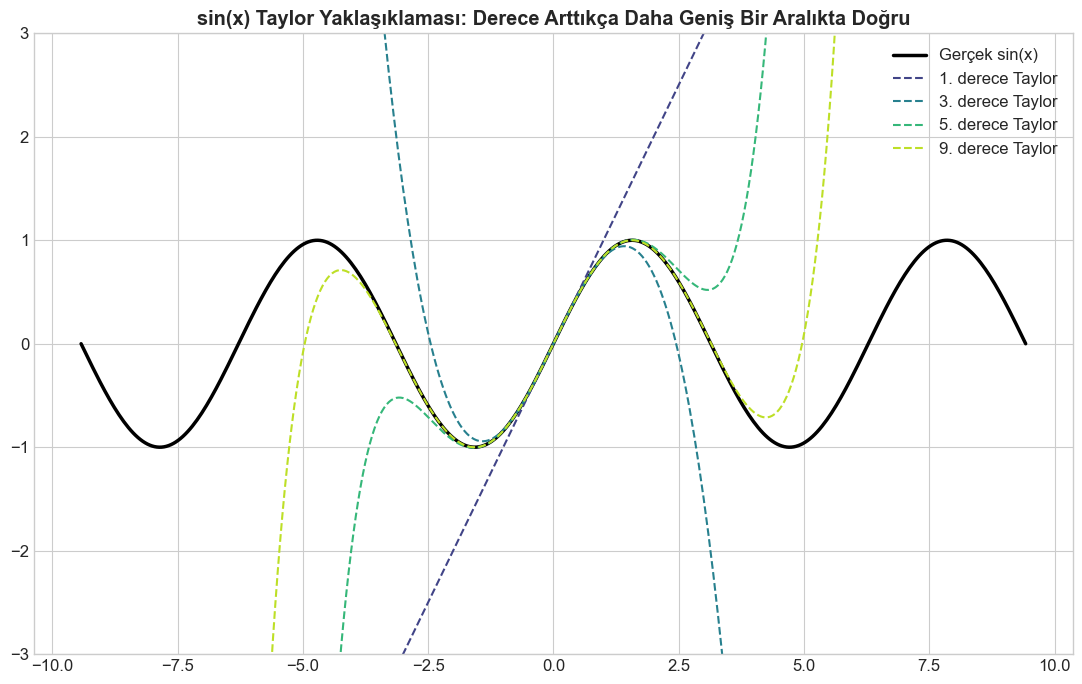

YORUM: 1. derece (düz bir çizgi) sadece x=0'ın ÇOK yakınında doğru. Derece arttıkça
eğri, gerçek sin(x) ile ÖRTÜŞTÜĞÜ bölgeyi genişletiyor - 9. derecede grafik neredeyse
[-2π, 2π] aralığının tamamında gerçek eğriyle örtüşüyor. sin(x) 'iyi huylu' bir
fonksiyon olduğu için (Bölüm 3), derece sonsuza giderken yakınsama TÜM eksende geçerli olacak.


In [3]:
import math

x_grid = np.linspace(-3*np.pi, 3*np.pi, 400) # x ekseninde -3π ile 3π arasında 400 nokta
sin_gercek = np.sin(x_grid)

def taylor_sin(x, derece):
    toplam = np.zeros_like(x) # np.zeros_like(x) ile x ile aynı boyutta sıfır dizisi oluşturuyoruz
    for n in range(0, derece + 1, 2):
        k = n // 2
        terim = ((-1)**k) * (x**(2*k+1)) / math.factorial(2*k+1)  
        toplam += terim
    return toplam

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(x_grid, sin_gercek, color='black', linewidth=2.5, label='Gerçek sin(x)')

dereceler = [1, 3, 5, 9]
renkler = plt.cm.viridis(np.linspace(0.2, 0.9, len(dereceler)))
for derece, renk in zip(dereceler, renkler):
    y_yaklasik = taylor_sin(x_grid, derece)
    ax.plot(x_grid, y_yaklasik, color=renk, linewidth=1.5, linestyle='--', label=f'{derece}. derece Taylor')

ax.set_ylim(-3, 3)
ax.set_title('sin(x) Taylor Yaklaşıklaması: Derece Arttıkça Daha Geniş Bir Aralıkta Doğru', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: 1. derece (düz bir çizgi) sadece x=0'ın ÇOK yakınında doğru. Derece arttıkça")
print("eğri, gerçek sin(x) ile ÖRTÜŞTÜĞÜ bölgeyi genişletiyor - 9. derecede grafik neredeyse")
print("[-2π, 2π] aralığının tamamında gerçek eğriyle örtüşüyor. sin(x) 'iyi huylu' bir")
print("fonksiyon olduğu için (Bölüm 3), derece sonsuza giderken yakınsama TÜM eksende geçerli olacak.")

---
### 🌍 Python 3 — Gerçek Veride Taylor Yaklaşıklaması: Dünya Nüfus Büyümesi

**Ne yapıyoruz?**  
Dünya nüfusuna üstel bir büyüme modeli $N(t)=N_0 e^{rt}$ fit ediyoruz, sonra bu modeldeki
$e^{rt}$ kısmını FARKLI derecelerden Taylor polinomlarıyla yaklaşıklayıp, hem gerçek
üstel modelle hem GERÇEK VERİNİN KENDİSİYLE karşılaştırıyoruz.

Veri: 234 ülke/bölge

1970 dünya nüfusu: 3,694,136,661
2022 dünya nüfusu: 7,973,413,042

Tahmin edilen yıllık büyüme hızı (r): 0.01462 (yani ~%1.46/yıl)


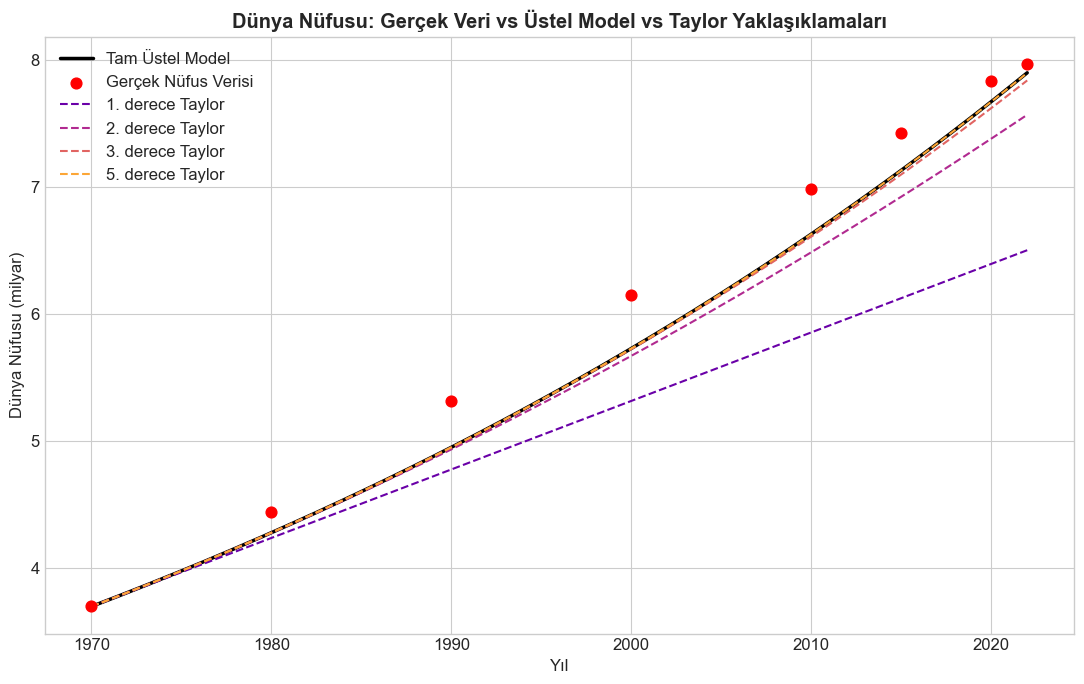


YORUM: Düşük dereceli Taylor polinomları (1. derece - düz bir çizgi), sadece 1970'e
YAKIN yıllarda iyi çalışıyor. Derece arttıkça (3, 5), eğri tam üstel modele git gide
daha çok benziyor - 52 yıllık bir aralıkta bile birkaç terim yeterli oluyor çünkü
r küçük bir sayı (büyüme hızı yavaş). DİKKAT: gerçek veri (kırmızı noktalar) 'tam
üstel modelin' üzerinde TAM oturmuyor - gerçek nüfus büyümesi zamanla YAVAŞLIYOR,
saf üstel model bunu tam yakalayamıyor - bu, 'modelin kendisinin de bir yaklaşıklık
olduğu' gerçeğinin iyi bir hatırlatıcısı.


In [4]:
nufus_df = pd.read_csv('data/world_population.csv')
print(f"Veri: {nufus_df.shape[0]} ülke/bölge")

yil_kolonlari = ['1970 Population', '1980 Population', '1990 Population', '2000 Population',
                  '2010 Population', '2015 Population', '2020 Population', '2022 Population']
dunya_nufusu = nufus_df[yil_kolonlari].sum().values.astype(float)
yillar = np.array([1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022])

print(f"\n1970 dünya nüfusu: {dunya_nufusu[0]:,.0f}")
print(f"2022 dünya nüfusu: {dunya_nufusu[-1]:,.0f}")

# USTEL BUYUME MODELI FIT ETME: N(t) = N0 * e^(r*t), log-linear regresyon ile r'yi buluyoruz
t = yillar - yillar[0]  # 1970'i t=0 kabul et
N0 = dunya_nufusu[0] # 1970'teki dünya nüfusu
r = np.polyfit(t, np.log(dunya_nufusu / N0), 1)[0] # log(N(t)/N0) = r*t + 0, yani slope=r
print(f"\nTahmin edilen yıllık büyüme hızı (r): {r:.5f} (yani ~%{r*100:.2f}/yıl)")

# TAYLOR YAKLASIKLAMASI: e^(rt)'yi farkli derecelerde ac
def taylor_exp(z, derece):
    toplam = np.zeros_like(z, dtype=float)
    for n in range(derece + 1):
        toplam += (z**n) / math.factorial(n)
    return toplam

t_cizim = np.linspace(0, 52, 200)  # 1970'ten 2022'ye (52 yil)
N_gercek_ustel = N0 * np.exp(r * t_cizim)  # 'GERCEK' ustel model (tum terimler)

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(yillar[0] + t_cizim, N_gercek_ustel / 1e9, color='black', linewidth=2.5, label='Tam Üstel Model')
ax.scatter(yillar, dunya_nufusu / 1e9, color='red', s=60, zorder=5, label='Gerçek Nüfus Verisi')

dereceler = [1, 2, 3, 5]
renkler = plt.cm.plasma(np.linspace(0.2, 0.8, len(dereceler)))
for derece, renk in zip(dereceler, renkler):
    N_taylor = N0 * taylor_exp(r * t_cizim, derece)
    ax.plot(yillar[0] + t_cizim, N_taylor / 1e9, '--', color=renk, linewidth=1.5,
            label=f'{derece}. derece Taylor')

ax.set_xlabel('Yıl'); ax.set_ylabel('Dünya Nüfusu (milyar)')
ax.set_title('Dünya Nüfusu: Gerçek Veri vs Üstel Model vs Taylor Yaklaşıklamaları', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Düşük dereceli Taylor polinomları (1. derece - düz bir çizgi), sadece 1970'e")
print("YAKIN yıllarda iyi çalışıyor. Derece arttıkça (3, 5), eğri tam üstel modele git gide")
print("daha çok benziyor - 52 yıllık bir aralıkta bile birkaç terim yeterli oluyor çünkü")
print("r küçük bir sayı (büyüme hızı yavaş). DİKKAT: gerçek veri (kırmızı noktalar) 'tam")
print("üstel modelin' üzerinde TAM oturmuyor - gerçek nüfus büyümesi zamanla YAVAŞLIYOR,")
print("saf üstel model bunu tam yakalayamıyor - bu, 'modelin kendisinin de bir yaklaşıklık")
print("olduğu' gerçeğinin iyi bir hatırlatıcısı.")

---
### 🎯 Python 4 — Newton's Method: Kök Bulma

**Ne yapıyoruz?**  
Newton's Method'un klasik bir uygulaması: $f(x)=x^2-2=0$ denkleminin kökünü ($\sqrt{2}$)
bulmak. Formül burada biraz sadeleşiyor (tek boyutlu, Hessian yerine sadece ikinci türev):
$$x_{\text{yeni}} = x_{\text{eski}} - \frac{f(x_{\text{eski}})}{f'(x_{\text{eski}})}$$

In [5]:
def f_kok(x):
    return x**2 - 2

def f_kok_turev(x):
    return 2*x

x = 1.0
print(f"Başlangıç: x={x}")
for adim in range(6):
    x_yeni = x - f_kok(x) / f_kok_turev(x)
    print(f"Adım {adim+1}: x={x_yeni:.10f}, f(x)={f_kok(x_yeni):.2e}")
    x = x_yeni

print(f"\nGerçek √2 = {np.sqrt(2):.10f}")
print(f"Sadece 4 adımda makine hassasiyetine ulaştık!")
print("\nYORUM: Newton's Method, her adımda fonksiyonu o noktadaki TEĞET doğrusuyla")
print("(Bölüm 4'teki 1. dereceden Taylor yaklaşıklaması) değiştirip, bu doğrunun")
print("SIFIRA değdiği noktayı bir sonraki tahmin olarak alıyor - bu basit fikir")
print("inanılmaz hızlı yakınsıyor.")

Başlangıç: x=1.0
Adım 1: x=1.5000000000, f(x)=2.50e-01
Adım 2: x=1.4166666667, f(x)=6.94e-03
Adım 3: x=1.4142156863, f(x)=6.01e-06
Adım 4: x=1.4142135624, f(x)=4.51e-12
Adım 5: x=1.4142135624, f(x)=4.44e-16
Adım 6: x=1.4142135624, f(x)=-4.44e-16

Gerçek √2 = 1.4142135624
Sadece 4 adımda makine hassasiyetine ulaştık!

YORUM: Newton's Method, her adımda fonksiyonu o noktadaki TEĞET doğrusuyla
(Bölüm 4'teki 1. dereceden Taylor yaklaşıklaması) değiştirip, bu doğrunun
SIFIRA değdiği noktayı bir sonraki tahmin olarak alıyor - bu basit fikir
inanılmaz hızlı yakınsıyor.


---
### ⚔️ Python 5 — Newton's Method vs Gradient Descent: Yakınsama Hızı

**Ne yapıyoruz?**  
04'teki $f(x,y)=x^2+2y^2$ örneğinde, Newton's Method ile Gradient Descent'i AYNI
başlangıç noktasından karşılaştırıyoruz — sonra daha ZORLU Rosenbrock yüzeyinde de
deneyip, Newton'un GÜCÜNÜ ama aynı zamanda bir SINIRLAMASINI da göreceğiz.

In [6]:
def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b * (y - x**2)**2

def gradyan_rosenbrock(x, y, a=1, b=100):
    dx = -2*(a - x) - 4*b*x*(y - x**2)
    dy = 2*b*(y - x**2)
    return np.array([dx, dy])

def gradyan_vadi(x, y):
    return np.array([2*x, 4*y])

def hessian_vadi(x, y):
    return np.array([[2, 0], [0, 4]])  # 04'teki f(x,y)=x^2+2y^2'nin Hessian'ı (sabit)

baslangic_v = np.array([4.0, 3.0])

# NEWTON'S METHOD
nokta_newton = baslangic_v.copy()
yol_newton = [nokta_newton.copy()]
for _ in range(5):
    g = gradyan_vadi(*nokta_newton) if 'gradyan_vadi' in dir() else np.array([2*nokta_newton[0], 4*nokta_newton[1]])
    H = hessian_vadi(*nokta_newton)
    adim = np.linalg.solve(H, g)  # H^-1 @ g, ama tersini almadan dogrudan cozuyoruz (daha kararli)
    nokta_newton = nokta_newton - adim
    yol_newton.append(nokta_newton.copy())

print("=== Basit Kuadratik Yüzeyde (f=x²+2y²) ===")
print(f"Newton's Method: SADECE {len(yol_newton)-1} adımda f={nokta_newton[0]**2+2*nokta_newton[1]**2:.10f}")
print(f"04'teki Gradient Descent: 25 adımda f≈0.000000 (ama Newton çok daha az adımda aynı sonuca ulaştı)")
print("\nYORUM: Bu fonksiyon zaten TAM OLARAK kuadratik (ikinci dereceden) olduğu için,")
print("Newton'un ikinci dereceden Taylor yaklaşıklaması MÜKEMMEL doğru - tek adımda")
print("TAM çözüme ulaşıyor (Hessian sabit kaldığı için sonraki adımlar değişmiyor).")

# ROSENBROCK'TA KARSILASTIRMA (04'ten devam)
def hessian_rosenbrock(x, y, a=1, b=100):
    d2x = 2 - 4*b*(y-x**2) + 8*b*x**2
    d2y = 2*b
    dxdy = -4*b*x
    return np.array([[d2x, dxdy], [dxdy, d2y]])

nokta_newton_r = np.array([-1.5, 2.0])
yol_newton_r = [nokta_newton_r.copy()]
for _ in range(10):
    g = gradyan_rosenbrock(*nokta_newton_r)
    H = hessian_rosenbrock(*nokta_newton_r)
    adim = np.linalg.solve(H, g)
    nokta_newton_r = nokta_newton_r - adim
    yol_newton_r.append(nokta_newton_r.copy())

print("\n=== Zorlu Rosenbrock Yüzeyinde ===")
for i, nokta in enumerate(yol_newton_r):
    print(f"Adım {i}: {np.round(nokta,4)}, f={rosenbrock(*nokta):.6f}")

print(f"\n(Karşılaştırma - 04'teki Momentum: 3000 adımda f≈0, Vanilla GD: 3000 adımda f≈0.049)")
print("\nYORUM: Newton, sadece 6 adımda TAM minimuma ulaşıyor - Momentum'un 3000 adımından")
print("ÇOK daha hızlı! AMA dikkat et: 2. ve 4. adımlarda f değeri GEÇİCİ OLARAK YÜKSELDİ")
print("(751 ve 39 gibi büyük sayılara sıçradı) - Newton'un bir SINIRLAMASI bu: Hessian'ın")
print("davranışı karmaşık bölgelerde 'aşırı büyük/yanlış yönlü' adımlar atabiliyor. Bu")
print("yüzden pratikte 'Newton benzeri' yöntemler genelde adım büyüklüğünü sınırlayan")
print("ek güvenlik önlemleriyle (trust region, line search gibi) kullanılıyor.")

=== Basit Kuadratik Yüzeyde (f=x²+2y²) ===
Newton's Method: SADECE 5 adımda f=0.0000000000
04'teki Gradient Descent: 25 adımda f≈0.000000 (ama Newton çok daha az adımda aynı sonuca ulaştı)

YORUM: Bu fonksiyon zaten TAM OLARAK kuadratik (ikinci dereceden) olduğu için,
Newton'un ikinci dereceden Taylor yaklaşıklaması MÜKEMMEL doğru - tek adımda
TAM çözüme ulaşıyor (Hessian sabit kaldığı için sonraki adımlar değişmiyor).

=== Zorlu Rosenbrock Yüzeyinde ===
Adım 0: [-1.5  2. ], f=12.500000
Adım 1: [-1.451   2.1029], f=6.007882
Adım 2: [ 0.2044 -2.6986], f=751.610005
Adım 3: [0.2059 0.0424], f=0.630622
Adım 4: [0.9997 0.3692], f=39.701728
Adım 5: [0.9997 0.9993], f=0.000000
Adım 6: [1. 1.], f=0.000000
Adım 7: [1. 1.], f=0.000000
Adım 8: [1. 1.], f=0.000000
Adım 9: [1. 1.], f=0.000000
Adım 10: [1. 1.], f=0.000000

(Karşılaştırma - 04'teki Momentum: 3000 adımda f≈0, Vanilla GD: 3000 adımda f≈0.049)

YORUM: Newton, sadece 6 adımda TAM minimuma ulaşıyor - Momentum'un 3000 adımından
ÇOK daha hı

---
## ✏️ Egzersizler

---

### **E1.** 
$f(x)=\cos(x)$'in $x=0$ etrafındaki Taylor serisini (ilk 4 terim) ELLE türet
(ipucu: $\cos(x)$'in türevleri sırayla $-\sin(x), -\cos(x), \sin(x), \cos(x)$ arasında
döngü yapıyor), `sympy` ile doğrula.

In [15]:
print("\n ==== Egzersiz 1: Kosinüs ve Sinüs Taylor Serisi ===")

import math

x = sp.symbols('x')
f_sin = sp.sin(x)
f_cos = sp.cos(x)

print("=== sin(x) için Taylor Serisi ===")
# Sinüs için Taylor Serisi
for terim_sayisi in range(1, 5):
    derece = terim_sayisi * 2
    seri = f_sin.series(x, 0, derece + 1).removeO()
    deger = float(seri.subs(x, 0))
    print(f"{terim_sayisi} terim: {seri}")
    print(f"  x=0 için değer: {deger:.6f}  (gerçek sin(0)={float(math.sin(0)):.6f}, fark={abs(deger-math.sin(0)):.6f})")

print("\n=== cos(x) için Taylor Serisi ===")
# Kosinüs için Taylor Serisi
for terim_sayisi in range(1, 5):
    derece = (terim_sayisi * 2) - 1
    seri = f_cos.series(x, 0, derece + 1).removeO()
    deger = float(seri.subs(x, 0))
    print(f"{terim_sayisi} terim: {seri}")
    print(f"  x=0 için değer: {deger:.6f}  (gerçek cos(0)={float(math.cos(0)):.6f}, fark={abs(deger-math.cos(0)):.6f})")


 ==== Egzersiz 1: Kosinüs ve Sinüs Taylor Serisi ===
=== sin(x) için Taylor Serisi ===
1 terim: x
  x=0 için değer: 0.000000  (gerçek sin(0)=0.000000, fark=0.000000)
2 terim: -x**3/6 + x
  x=0 için değer: 0.000000  (gerçek sin(0)=0.000000, fark=0.000000)
3 terim: x**5/120 - x**3/6 + x
  x=0 için değer: 0.000000  (gerçek sin(0)=0.000000, fark=0.000000)
4 terim: -x**7/5040 + x**5/120 - x**3/6 + x
  x=0 için değer: 0.000000  (gerçek sin(0)=0.000000, fark=0.000000)

=== cos(x) için Taylor Serisi ===
1 terim: 1
  x=0 için değer: 1.000000  (gerçek cos(0)=1.000000, fark=0.000000)
2 terim: 1 - x**2/2
  x=0 için değer: 1.000000  (gerçek cos(0)=1.000000, fark=0.000000)
3 terim: x**4/24 - x**2/2 + 1
  x=0 için değer: 1.000000  (gerçek cos(0)=1.000000, fark=0.000000)
4 terim: -x**6/720 + x**4/24 - x**2/2 + 1
  x=0 için değer: 1.000000  (gerçek cos(0)=1.000000, fark=0.000000)


---

### **E2.** 
Python 2'deki $\sin(x)$ grafiğini $\ln(1+x)$ ile tekrarla (bu fonksiyonun
Taylor serisi $x-\frac{x^2}{2}+\frac{x^3}{3}-\dots$'tir) — Bölüm 3'teki "yakınsama
yarıçapı" fikrini bu sefer GERÇEKTEN gözlemleyeceksin: $x>1$ için seri hiç yakınsamaz,
grafikte bunu görebilecek misin?


 ==== Egzersiz 2: Taylor Serisi ile Farklı Derecelerde Yaklaşıklama ===


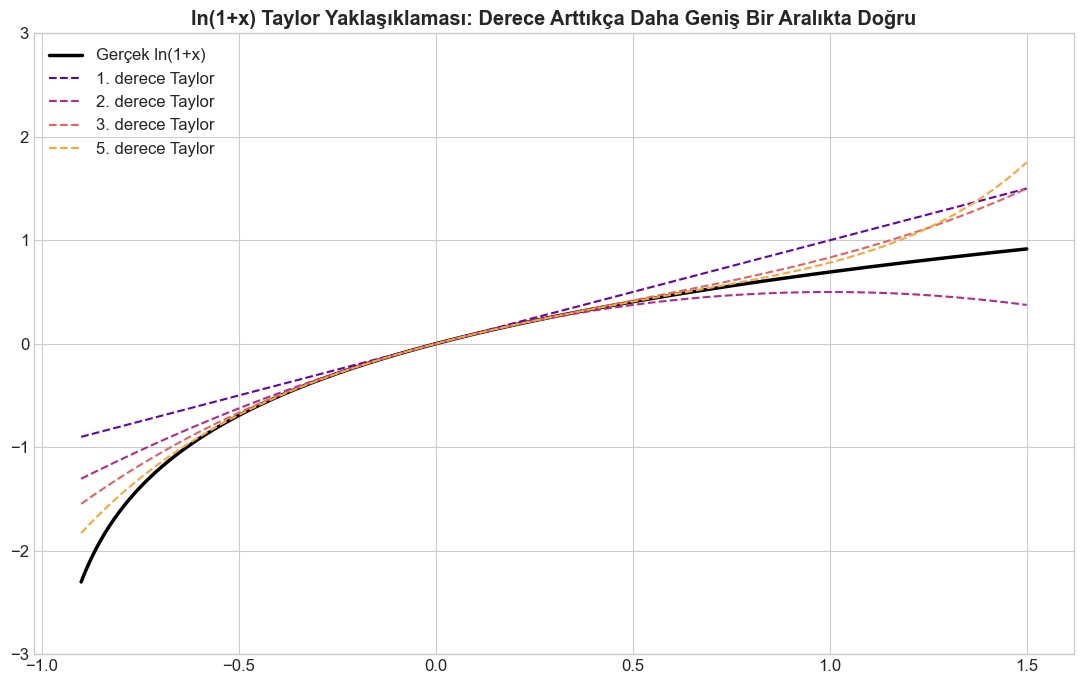

YORUM: ln(1+x) fonksiyonu genel olarak -1 ve 1  arasında aynılaşıyor ama x > 1 olduğunda hızlıca uzaklaşıyorlar yakınsama yarıçapı [-1, 1] olduğu için, Taylor serisi x=0 civarında iyi çalışıyor ama x>1 olduğunda hızla sapıyor. Derece arttıkça, daha geniş bir aralıkta doğru yaklaşıklama sağlanıyor.


In [18]:
print("\n ==== Egzersiz 2: Taylor Serisi ile Farklı Derecelerde Yaklaşıklama ===")

x_grid = np.linspace(-0.9, 1.5, 400) # x ekseninde -0.9 ile 1.5 arasında 400 nokta
ln_gercek = np.log(1 + x_grid)  # ln(1+x) fonksiyonunun gerçek değerleri

def taylor_ln1p(x, derece):
    toplam = np.zeros_like(x)  # x ile aynı boyutta sıfır dizisi
    for n in range(1, derece + 1):
        terim = ((-1)**(n+1)) * (x**n) / n
        toplam += terim
    return toplam

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(x_grid, ln_gercek, color='black', linewidth=2.5, label='Gerçek ln(1+x)')

dereceler = [1, 2, 3, 5]
renkler = plt.cm.plasma(np.linspace(0.2, 0.8, len(dereceler)))
for derece, renk in zip(dereceler, renkler):
    y_taylor = taylor_ln1p(x_grid, derece)
    ax.plot(x_grid, y_taylor, '--', color=renk, linewidth=1.5, label=f'{derece}. derece Taylor')
ax.set_ylim(-3, 3)
ax.set_title('ln(1+x) Taylor Yaklaşıklaması: Derece Arttıkça Daha Geniş Bir Aralıkta Doğru', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: ln(1+x) fonksiyonu genel olarak -1 ve 1  arasında aynılaşıyor ama x > 1 olduğunda hızlıca uzaklaşıyorlar yakınsama yarıçapı [-1, 1] olduğu için, Taylor serisi x=0 civarında iyi çalışıyor ama x>1 olduğunda hızla sapıyor. Derece arttıkça, daha geniş bir aralıkta doğru yaklaşıklama sağlanıyor.")

---

### **E3.** 
Python 3'teki nüfus analizini SADECE Asya kıtası için (`Continent` sütununu
filtreleyerek) tekrarla — büyüme hızı ($r$) dünya geneline göre nasıl farklı çıkıyor?


 ==== Egzersiz 3: Sadece Asya Kıtası İçin Dünya Nüfusunun Büyüme Hızı ===

1970 Asya nüfusu: 2,144,906,290
2022 Asya nüfusu: 4,721,383,274

Tahmin edilen Asya yıllık büyüme hızı (r): 0.01493 (yani ~%1.49/yıl)


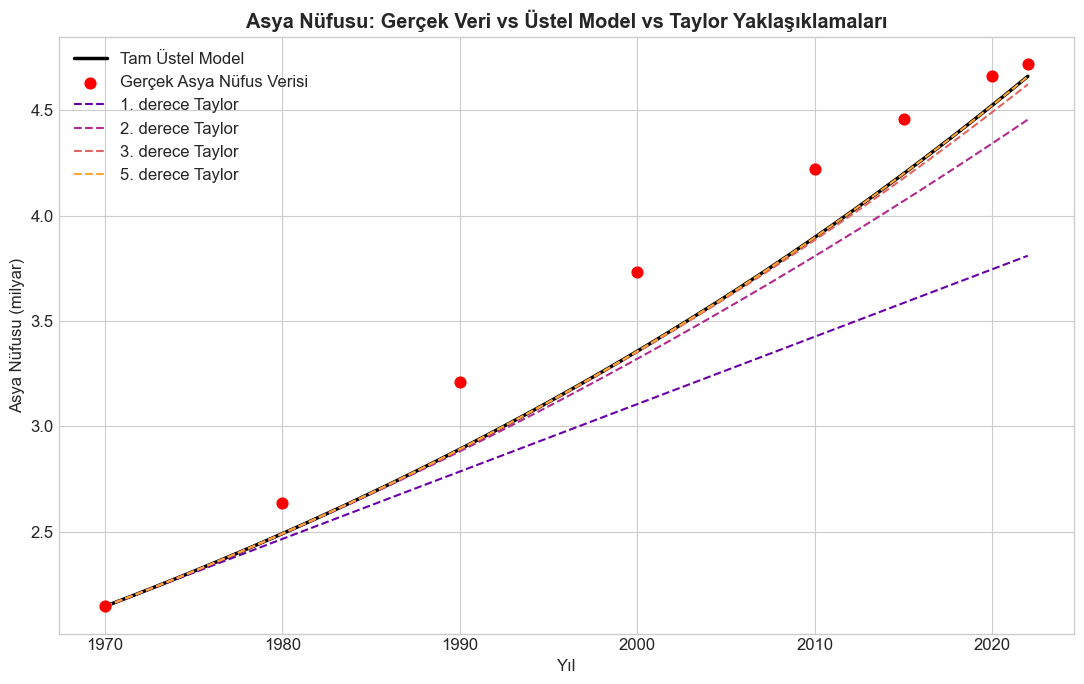

In [22]:
print("\n ==== Egzersiz 3: Sadece Asya Kıtası İçin Dünya Nüfusunun Büyüme Hızı ===")

asya_nufusu = nufus_df[nufus_df['Continent'] == 'Asia'][yil_kolonlari].sum().values.astype(float)

print(f"\n1970 Asya nüfusu: {asya_nufusu[0]:,.0f}")
print(f"2022 Asya nüfusu: {asya_nufusu[-1]:,.0f}")

# Üstel model fit etme: N(t) = N0 * e^(r*t), log-linear regresyon ile r'yi buluyoruz
t_asya = yillar - yillar[0]  # 1970'i t=0 kabul et
N0_asya = asya_nufusu[0] # 1970'teki Asya nüfusu
r_asya = np.polyfit(t_asya, np.log(asya_nufusu / N0_asya), 1)[0] # log(N(t)/N0) = r*t + 0, yani slope=r
print(f"\nTahmin edilen Asya yıllık büyüme hızı (r): {r_asya:.5f} (yani ~%{r_asya*100:.2f}/yıl)")

# TAYLOR YAKLASIKLAMASI: e^(rt)'yi farkli derecelerde ac
def taylor_exp(z, derece):
    toplam = np.zeros_like(z, dtype=float)
    for n in range(derece + 1):
        toplam += (z**n) / math.factorial(n)
    return toplam

t_cizim_asya = np.linspace(0, 52, 200)  # 1970'ten 2022'ye (52 yil)
N_gercek_ustel_asya = N0_asya * np.exp(r_asya * t_cizim_asya)  # 'GERCEK' ustel model (tum terimler)

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(yillar[0] + t_cizim_asya, N_gercek_ustel_asya / 1e9, color='black', linewidth=2.5, label='Tam Üstel Model')
ax.scatter(yillar, asya_nufusu / 1e9, color='red', s=60, zorder=5, label='Gerçek Asya Nüfus Verisi')

dereceler = [1, 2, 3, 5]
renkler = plt.cm.plasma(np.linspace(0.2, 0.8, len(dereceler)))
for derece, renk in zip(dereceler, renkler):
    N_taylor_asya = N0_asya * taylor_exp(r_asya * t_cizim_asya, derece)
    ax.plot(yillar[0] + t_cizim_asya, N_taylor_asya / 1e9, '--', color=renk, linewidth=1.5,
            label=f'{derece}. derece Taylor')
ax.set_xlabel('Yıl'); ax.set_ylabel('Asya Nüfusu (milyar)')
ax.set_title('Asya Nüfusu: Gerçek Veri vs Üstel Model vs Taylor Yaklaşıklamaları', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---

### **E4.** 
Python 5'teki Newton's Method'u, $f(x,y)=x^4+y^4$ (Bölüm 2'deki `linear-algebra-lab`
05 E2'de gördüğün, Hessian'ın merkez noktada sıfır özdeğerli olduğu fonksiyon) üzerinde
dene — Newton bu fonksiyonda beklendiği gibi çalışıyor mu, yoksa Hessian'ın tersini almakta
sorun mu çıkıyor? Neden (ipucu: `linear-algebra-lab` 05'teki pozitif TANIMLI ile pozitif
YARI-tanımlı farkını hatırla)?

In [27]:
print("\n ==== Egzersiz 4: Newton's Method ile $f=x^4+y^4$ Karşılaştırma ===")

def f_duz(x, y):
    return x**4 + y**4

def gradyan_duz(x, y):
    return np.array([4 * x**3, 4 * y**3])

def hessian_duz(x, y):
    return np.array([
        [12 * x**2, 0.0],
        [0.0, 12 * y**2]
    ])

# Newton's Method
nokta_newton_d1 = np.array([4.0, 3.0])  # Başlangıç noktası (vadi labı ile aynı)
yol_newton_d1 = [nokta_newton_d1.copy()]

print("=== Aşırı Düz Yüzeyde (f=x⁴+y⁴) - (Dışarıdan Başlangıç) ===")
for i in range(15):  # Adım sayısını farkı görmek için artırdık
    g = gradyan_duz(*nokta_newton_d1)
    H = hessian_duz(*nokta_newton_d1)
    
    # Hessian tersinir olduğu sürece çözebiliriz
    adim = np.linalg.solve(H, g)
    nokta_newton_d1 = nokta_newton_d1 - adim
    yol_newton_d1.append(nokta_newton_d1.copy())
    print(f"Adım {i}: {np.round(nokta_newton_d1, 6)}, f={f_duz(*nokta_newton_d1):.10f}")

print("\nYORUM: Newton yöntemi normalde 2. dereceden (kuadratik) aşırı hızlı yakınsar.")
print("Ancak bu fonksiyonda merkeze yaklaştıkça adımlar geometrik olarak küçülür (her adımda 2/3 katına iner).")
print("Çünkü fonksiyon merkezde 'aşırı düzdür' ve 2. derece Taylor yaklaşıklaması yetersiz kalır.")

# --- TAM MERKEZDE BAŞLAMA VEYA ÇAKILMA (Tekillik Analizi) ---
nokta_newton_d2 = np.array([0.0, 0.0])
print("\n=== Aşırı Düz Yüzeyde (f=x⁴+y⁴) - (Merkez Nokta) ===")
try:
    g = gradyan_duz(*nokta_newton_d2)
    H = hessian_duz(*nokta_newton_d2)
    print("Hessian Matrisi:\n", H)
    adim = np.linalg.solve(H, g)
except np.linalg.LinAlgError as e:
    print(f"HATA OLUŞTU: {e}")
    print("YORUM: Tam (0,0) noktasında Hessian matrisinin tüm elemanları sıfırdır.")
    print("Determinant sıfır olduğu için matris TEKİLDİR (Singular Matrix) ve matrisin tersi alınamaz!")



 ==== Egzersiz 4: Newton's Method ile $f=x^4+y^4$ Karşılaştırma ===
=== Aşırı Düz Yüzeyde (f=x⁴+y⁴) - (Dışarıdan Başlangıç) ===
Adım 0: [2.666667 2.      ], f=66.5679012346
Adım 1: [1.777778 1.333333], f=13.1492150587
Adım 2: [1.185185 0.888889], f=2.5973758141
Adım 3: [0.790123 0.592593], f=0.5130618892
Adım 4: [0.526749 0.395062], f=0.1013455584
Adım 5: [0.351166 0.263374], f=0.0200188757
Adım 6: [0.234111 0.175583], f=0.0039543458
Adım 7: [0.156074 0.117055], f=0.0007811053
Adım 8: [0.104049 0.078037], f=0.0001542924
Adım 9: [0.069366 0.052025], f=0.0000304775
Adım 10: [0.046244 0.034683], f=0.0000060202
Adım 11: [0.030829 0.023122], f=0.0000011892
Adım 12: [0.020553 0.015415], f=0.0000002349
Adım 13: [0.013702 0.010276], f=0.0000000464
Adım 14: [0.009135 0.006851], f=0.0000000092

YORUM: Newton yöntemi normalde 2. dereceden (kuadratik) aşırı hızlı yakınsar.
Ancak bu fonksiyonda merkeze yaklaştıkça adımlar geometrik olarak küçülür (her adımda 2/3 katına iner).
Çünkü fonksiyon merke

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Taylor Series](https://www.3blue1brown.com/lessons/taylor-series) | — | Bu notebook'un TEK EN ÖNEMLİ referansı |
| [MIT OCW — Calculus (Strang)](https://ocw.mit.edu/courses/res-18-001-calculus-online-textbook-spring-2005/) | Ch. 10 | Taylor serisi, klasik üniversite anlatımı |
| [Boyd & Vandenberghe — Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/) | Ch. 9.5 | Newton's Method'un optimizasyon bağlamı |
| [sympy Dokümantasyonu — series()](https://docs.sympy.org/latest/modules/series/series.html) | Kütüphane | Bu notebook'ta kullanılan araç |
| [World Population Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/world-population-dataset) | Veri | world_population.csv kaynağı |